## 加载训练好的模型

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np

#   Network definition
class OneD_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=10, kernel_size=1, stride=1)
        self.conv1_2 = nn.Conv1d(in_channels=10, out_channels=10, kernel_size=1, stride=1)
        self.downConv1 = nn.Conv1d(in_channels=10, out_channels=10,kernel_size=9, stride=2)

        self.conv2_1 = nn.Conv1d(in_channels=10, out_channels=13,kernel_size=1, stride=1)
        self.downConv2 = nn.Conv1d(in_channels=13, out_channels=13, kernel_size=9, stride=2)

        self.conv3_1 = nn.Conv1d(in_channels=13, out_channels=18, kernel_size=1, stride=1)
        self.downConv3 = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=11, stride=2)

        self.conv4_1 = nn.Conv1d(in_channels=18, out_channels=24, kernel_size=1, stride=1)
        self.downConv4 = nn.Conv1d(in_channels=24, out_channels=24, kernel_size=9, stride=2)

        self.conv5_1 = nn.Conv1d(in_channels=24, out_channels=34, kernel_size=1, stride=1)
        self.upConv1 = nn.ConvTranspose1d(in_channels=34, out_channels=24, kernel_size=9, stride=2)

        self.conv6_1 = nn.Conv1d(in_channels=48, out_channels=24, kernel_size=1, stride=1)
        self.upConv2 = nn.ConvTranspose1d(in_channels=24, out_channels=18, kernel_size=11, stride=2)

        self.conv7_1 = nn.Conv1d(in_channels=36, out_channels=18, kernel_size=1, stride=1)
        self.upConv3 = nn.ConvTranspose1d(in_channels=18, out_channels=13, kernel_size=9, stride=2)

        self.conv8_1 = nn.Conv1d(in_channels=26, out_channels=13, kernel_size=1, stride=1)
        self.upConv4 = nn.ConvTranspose1d(in_channels=13, out_channels=10, kernel_size=9, stride=2)

        self.conv_9_1 = nn.Conv1d(in_channels=20, out_channels=10, kernel_size=1, stride=1)
        self.convOutput = nn.Conv1d(in_channels=10, out_channels=2, kernel_size=1, stride=1)

    def forward(self,x):
        x = self.conv1_1(x)
        x = torch.tanh(self.conv1_2(x))
        Intermediate1 = x   #  cropping to copy
        x = torch.tanh(self.downConv1(x))

        x = torch.tanh(self.conv2_1(x))
        Intermediate2 = x   #  cropping to copy
        x = torch.tanh(self.downConv2(x))

        x = torch.tanh(self.conv3_1(x))
        Intermediate3 = x   #  cropping to copy
        x = torch.tanh(self.downConv3(x))

        x = torch.tanh(self.conv4_1(x))
        Intermediate4 = x   #  cropping to copy
        x = torch.tanh(self.downConv4(x))

        x = torch.tanh(self.conv5_1(x))
        x = torch.tanh(self.upConv1(x))

        x = torch.tanh(self.conv6_1(torch.cat((Intermediate4,x),1)))
        x = torch.tanh(self.upConv2(x))

        x = torch.tanh(self.conv7_1(torch.cat((Intermediate3,x),1)))
        x = torch.tanh(self.upConv3(x))

        x = torch.tanh(self.conv8_1(torch.cat((Intermediate2,x),1)))
        x = torch.tanh(self.upConv4(x))

        x = torch.tanh(self.conv_9_1(torch.cat((Intermediate1,x),1)))
        x = torch.tanh(self.convOutput(x))
        voice = x[:,0,:]
        prob = torch.tanh(x[:,1,:])

        return voice,prob
        
        

In [115]:
MODEL_PATH = './models/fileCount is 1000,loss is 1.1547837857506238e-05.pth'
net = torch.load(MODEL_PATH).cpu()

In [111]:
INPUT_WAV_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_noised/common_voice_zh-CN_18531660_WAV.wav'
TARGET_WAV_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_denoised/common_voice_zh-CN_18531660_WAV.wav'
OUTPUT_WAV_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/waw_fortest/common_voice_zh-CN_18531660_WAV.wav'

origin,_ = librosa.load(INPUT_WAV_PATH, sr=16000)

In [116]:
#补齐数据
origin = np.concatenate((origin,np.zeros(3201-len(origin)%3201)),0)
wav = torch.Tensor(origin).view(-1,1,1,3201)
prop = torch.randn_like(wav)
for i in range(len(wav)):
    wav[i],prop[i] = net(wav[i])
wav = wav.detach().view(-1).numpy()
prop = prop.detach().view(-1).numpy()

sf.write(OUTPUT_WAV_PATH,wav,16000)


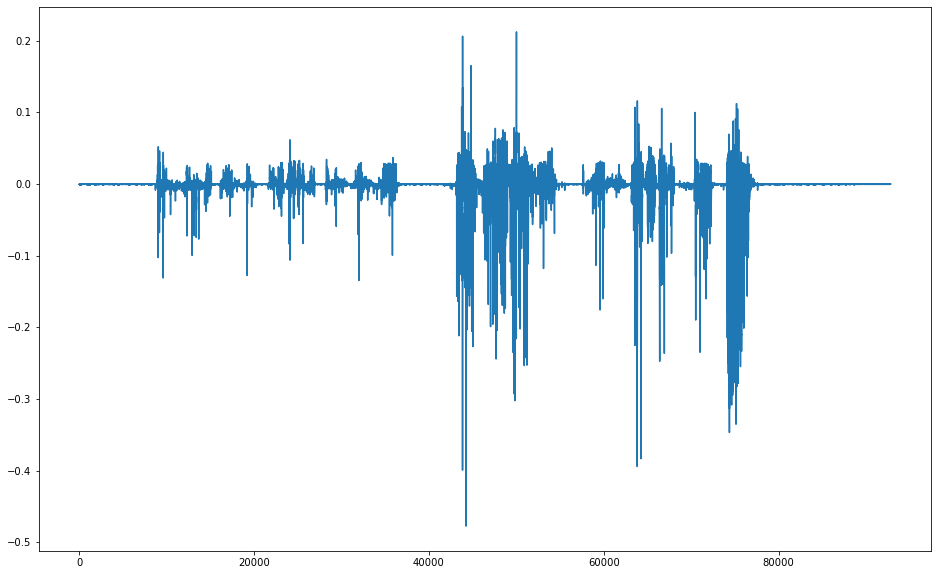

In [118]:
real,_ = librosa.load(TARGET_WAV_PATH,16000)
plt.figure(figsize=(16,10))
plt.plot(range(len(wav)),wav)
#plt.plot(range(len(prop)),prop)
#plt.plot(range(len(real)),real)

plt.show()